# English to Kamba Machine Translation (V4)
**Architecture**: `Helsinki-NLP/opus-mt-en-bnt` (Marian NMT)
**Method**: Full Parameter Fine-Tuning (FP16/BF16)

This notebook fully fine-tunes a specialized English-to-Bantu translation model specifically for Kamba.

## 1. Setup & Data Loading

In [1]:
import os

import os
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

!pip install -q transformers datasets sentencepiece sacrebleu evaluate accelerate tqdm gradio

import gc
import torch

try:
    del trainer
    del model
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()
print("GPU Memory explicitly flushed before initial pipeline execution.")

from datasets import load_dataset
import warnings
warnings.filterwarnings("ignore")
import logging
warnings.filterwarnings("ignore", category=UserWarning, module="huggingface_hub.*")
logging.getLogger("huggingface_hub.utils._http").setLevel(logging.ERROR)
import logging
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)
logging.getLogger("accelerate.utils.modeling").setLevel(logging.ERROR)
logging.getLogger("accelerate.big_modeling").setLevel(logging.ERROR)
logging.getLogger("accelerate").setLevel(logging.ERROR)

dataset = load_dataset("michsethowusu/english-kamba_sentence-pairs_mt560")
print("Dataset Loaded:\n", dataset)

if "validation" not in dataset:
    if "train" in dataset:
        dataset = dataset["train"].train_test_split(test_size=0.05, seed=42)
        dataset["validation"] = dataset.pop("test")
    else:
        dataset = dataset.train_test_split(test_size=0.05, seed=42)
        dataset["validation"] = dataset.pop("test")

print("\nAfter Split:\n", dataset)

Drive already mounted.
GPU Memory explicitly flushed before initial pipeline execution.
Dataset Loaded:
 DatasetDict({
    train: Dataset({
        features: ['eng', 'kam'],
        num_rows: 51054
    })
})

After Split:
 DatasetDict({
    train: Dataset({
        features: ['eng', 'kam'],
        num_rows: 48501
    })
    validation: Dataset({
        features: ['eng', 'kam'],
        num_rows: 2553
    })
})


## 2. Preprocessing & Tokenization

In [2]:
from transformers import AutoTokenizer
import multiprocessing

model_checkpoint = "Helsinki-NLP/opus-mt-en-bnt"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

max_length = 128

def preprocess_function(examples):
    keys = list(examples.keys())
    if "translation" in keys:
        en_texts = [ex["en"] for ex in examples["translation"]]
        kam_texts = [ex["kam"] for ex in examples["translation"]]
    else:
        en_col = next((c for c in ["english", "en", "English", "source"] if c in keys), keys[0])
        kam_col = next((c for c in ["kamba", "kam", "Kamba", "target"] if c in keys), keys[1])
        en_texts = [str(ex) for ex in examples[en_col]]
        kam_texts = [str(ex) for ex in examples[kam_col]]
    
    # Tokenize the source texts (English)
    model_inputs = tokenizer(en_texts, max_length=max_length, truncation=True, padding="max_length")
    
    # Tokenize the target texts (Kamba)
    labels = tokenizer(text_target=kam_texts, max_length=max_length, truncation=True, padding="max_length")
    
    # Ignore padding tokens in the loss calculation
    labels_with_ignore_index = [
        [l if l != tokenizer.pad_token_id else -100 for l in label_sequence] for label_sequence in labels["input_ids"]
    ]
    model_inputs["labels"] = labels_with_ignore_index
    
    return model_inputs

num_cores = multiprocessing.cpu_count()
print(f"Using {num_cores} cores for tokenization...")

column_names = dataset["train"].column_names if "train" in dataset else dataset.column_names

tokenized_datasets = dataset.map(
    preprocess_function, 
    batched=True, 
    num_proc=num_cores,
    remove_columns=column_names
)

Using 12 cores for tokenization...


## 3. Full Model Fine-Tuning

In [3]:
import torch
import os
from transformers import AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Hardware Device: {device.upper()}")

# Load the FULL model (No QLoRA or 4-bit!)
import logging
import logging
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)
logging.getLogger("accelerate.utils.modeling").setLevel(logging.ERROR)
logging.getLogger("accelerate.big_modeling").setLevel(logging.ERROR)
logging.getLogger("accelerate").setLevel(logging.ERROR)
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

import evaluate
import numpy as np

sacrebleu_metric = evaluate.load("sacrebleu")
chrf_metric = evaluate.load("chrf")

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [[label.strip()] for label in decoded_labels]

    bleu_result = sacrebleu_metric.compute(predictions=decoded_preds, references=decoded_labels, force=True)
    chrf_result = chrf_metric.compute(predictions=decoded_preds, references=decoded_labels)

    return {"bleu": bleu_result["score"], "chrf": chrf_result["score"]}

batch_size = 32 # Marian is small, we can use a larger batch size!

# Set output directory directly to Google Drive
output_dir = "/content/drive/MyDrive/Kamba_Translation_Project/marian-english-kamba/checkpoints"

args = Seq2SeqTrainingArguments(
    output_dir,
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    learning_rate=5e-5, # Standard learning rate for full fine-tuning
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=2, 
    weight_decay=0.01,
    save_total_limit=3, # Keeps the last 3 checkpoints on Drive to save space
    num_train_epochs=5,
    predict_with_generate=True,
    generation_max_length=128,
    bf16=True, # Fast, stable training on L4
    dataloader_num_workers=8,
    dataloader_pin_memory=True,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model,
    args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

# Check if there's a valid checkpoint to resume from
last_checkpoint = None
if os.path.isdir(output_dir):
    checkpoints = [d for d in os.listdir(output_dir) if d.startswith("checkpoint")]
    if checkpoints:
        last_checkpoint = True # Tell trainer to automatically find the latest
        print(f"\nResuming training from checkpoint in {output_dir}")

trainer.train(resume_from_checkpoint=last_checkpoint)

Hardware Device: CUDA


The following layers were not sharded: final_logits_bias, model.shared.weight, model.decoder.layers.*.self_attn.v_proj.bias, model.decoder.layers.*.encoder_attn.k_proj.bias, model.decoder.layers.*.encoder_attn.out_proj.weight, model.decoder.layers.*.encoder_attn.v_proj.weight, model.decoder.layers.*.encoder_attn.out_proj.bias, model.decoder.layers.*.self_attn.k_proj.bias, model.encoder.embed_tokens.weight, model.decoder.layers.*.fc1.weight, model.decoder.layers.*.self_attn.q_proj.bias, model.encoder.layers.*.fc2.bias, model.encoder.layers.*.self_attn.v_proj.weight, model.encoder.layers.*.final_layer_norm.bias, model.decoder.layers.*.encoder_attn.v_proj.bias, model.encoder.layers.*.final_layer_norm.weight, model.decoder.embed_tokens.weight, model.encoder.layers.*.self_attn_layer_norm.weight, model.encoder.layers.*.fc1.bias, model.encoder.layers.*.fc2.weight, model.encoder.embed_positions.weight, model.decoder.layers.*.fc1.bias, model.encoder.layers.*.self_attn.k_proj.bias, model.decoder

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.



Resuming training from checkpoint in /content/drive/MyDrive/Kamba_Translation_Project/marian-english-kamba/checkpoints


There were missing keys in the checkpoint model loaded: ['model.encoder.embed_positions.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


Step,Training Loss,Validation Loss


TrainOutput(global_step=3790, training_loss=0.0, metrics={'train_runtime': 0.0036, 'train_samples_per_second': 67552612.839, 'train_steps_per_second': 1055748.965, 'total_flos': 8220522986864640.0, 'train_loss': 0.0, 'epoch': 5.0})

## 4. Save English -> Kamba Model & Logs


In [4]:
# Force a final evaluation at the very end of training!
print("Running final EN->KAM evaluation...")
trainer.evaluate()

# Extract logs before flushing memory!
log_history_en_kam = list(trainer.state.log_history)
print("\nFinal EN->KAM Metrics:", {k: v for k, v in log_history_en_kam[-1].items() if 'eval' in k})

final_model_dir_en_kam = "/content/drive/MyDrive/Kamba_Translation_Project/marian-english-kamba/final"
model.save_pretrained(final_model_dir_en_kam)
tokenizer.save_pretrained(final_model_dir_en_kam)
print(f"Fully fine-tuned EN->KAM model saved to {final_model_dir_en_kam}")

Running final EN->KAM evaluation...



Final EN->KAM Metrics: {'eval_loss': 1.0110142230987549, 'eval_bleu': 24.979054234099785, 'eval_chrf': 48.26418361061558, 'eval_runtime': 151.5035, 'eval_samples_per_second': 16.851, 'eval_steps_per_second': 0.528}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fully fine-tuned EN->KAM model saved to /content/drive/MyDrive/Kamba_Translation_Project/marian-english-kamba/final


## 5. Reverse Pipeline (Kamba -> English)


In [5]:
import gc
import torch

# Free up memory from the previous training run to prevent Colab OOM crashes
try:
    del trainer
    del model
    del data_collator
    del tokenized_datasets
    del dataset
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()
print("GPU Memory flushed for reverse training.")

GPU Memory flushed for reverse training.


In [6]:
from datasets import load_dataset
from transformers import AutoTokenizer
import multiprocessing

dataset_rev = load_dataset("michsethowusu/english-kamba_sentence-pairs_mt560")

if "validation" not in dataset_rev:
    if "train" in dataset_rev:
        dataset_rev = dataset_rev["train"].train_test_split(test_size=0.05, seed=42)
        dataset_rev["validation"] = dataset_rev.pop("test")
    else:
        dataset_rev = dataset_rev.train_test_split(test_size=0.05, seed=42)
        dataset_rev["validation"] = dataset_rev.pop("test")

model_checkpoint_rev = "Helsinki-NLP/opus-mt-bnt-en"
tokenizer_rev = AutoTokenizer.from_pretrained(model_checkpoint_rev)

max_length = 128

def preprocess_function_rev(examples):
    keys = list(examples.keys())
    if "translation" in keys:
        en_texts = [ex["en"] for ex in examples["translation"]]
        kam_texts = [ex["kam"] for ex in examples["translation"]]
    else:
        en_col = next((c for c in ["english", "en", "English", "source"] if c in keys), keys[0])
        kam_col = next((c for c in ["kamba", "kam", "Kamba", "target"] if c in keys), keys[1])
        en_texts = [str(ex) for ex in examples[en_col]]
        kam_texts = [str(ex) for ex in examples[kam_col]]
    
    # REVERSE: Tokenize the source texts (Kamba)
    model_inputs = tokenizer_rev(kam_texts, max_length=max_length, truncation=True, padding="max_length")
    
    # REVERSE: Tokenize the target texts (English)
    labels = tokenizer_rev(text_target=en_texts, max_length=max_length, truncation=True, padding="max_length")
    
    # Ignore padding tokens in the loss calculation
    labels_with_ignore_index = [
        [l if l != tokenizer_rev.pad_token_id else -100 for l in label_sequence] for label_sequence in labels["input_ids"]
    ]
    model_inputs["labels"] = labels_with_ignore_index
    
    return model_inputs

num_cores = multiprocessing.cpu_count()
column_names_rev = dataset_rev["train"].column_names if "train" in dataset_rev else dataset_rev.column_names

tokenized_datasets_rev = dataset_rev.map(
    preprocess_function_rev, 
    batched=True, 
    num_proc=num_cores,
    remove_columns=column_names_rev
)

In [7]:
import os
from transformers import AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments
import evaluate
import numpy as np

# Load the REVERSE FULL model
import logging
import logging
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)
logging.getLogger("accelerate.utils.modeling").setLevel(logging.ERROR)
logging.getLogger("accelerate.big_modeling").setLevel(logging.ERROR)
logging.getLogger("accelerate").setLevel(logging.ERROR)
model_rev = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint_rev)

data_collator_rev = DataCollatorForSeq2Seq(tokenizer_rev, model=model_rev)

sacrebleu_metric_rev = evaluate.load("sacrebleu")
chrf_metric_rev = evaluate.load("chrf")

def compute_metrics_rev(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.where(preds != -100, preds, tokenizer_rev.pad_token_id)
    decoded_preds = tokenizer_rev.batch_decode(preds, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer_rev.pad_token_id)
    decoded_labels = tokenizer_rev.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [[label.strip()] for label in decoded_labels]

    bleu_result = sacrebleu_metric_rev.compute(predictions=decoded_preds, references=decoded_labels, force=True)
    chrf_result = chrf_metric_rev.compute(predictions=decoded_preds, references=decoded_labels)

    return {"bleu": bleu_result["score"], "chrf": chrf_result["score"]}

batch_size = 32

output_dir_rev = "/content/drive/MyDrive/Kamba_Translation_Project/marian-kamba-english/checkpoints"

args_rev = Seq2SeqTrainingArguments(
    output_dir_rev,
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    learning_rate=5e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=2, 
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=5,
    predict_with_generate=True,
    generation_max_length=128,
    bf16=True,
    dataloader_num_workers=8,
    dataloader_pin_memory=True,
    report_to="none"
)

trainer_rev = Seq2SeqTrainer(
    model_rev,
    args_rev,
    train_dataset=tokenized_datasets_rev["train"],
    eval_dataset=tokenized_datasets_rev["validation"],
    data_collator=data_collator_rev,
    processing_class=tokenizer_rev,
    compute_metrics=compute_metrics_rev,
)

last_checkpoint_rev = None
if os.path.isdir(output_dir_rev):
    checkpoints = [d for d in os.listdir(output_dir_rev) if d.startswith("checkpoint")]
    if checkpoints:
        last_checkpoint_rev = True
        print(f"\nResuming reverse training from checkpoint in {output_dir_rev}")

trainer_rev.train(resume_from_checkpoint=last_checkpoint_rev)

# Force a final evaluation at the very end of reverse training!
print("Running final KAM->EN evaluation...")
trainer_rev.evaluate()

log_history_kam_en = list(trainer_rev.state.log_history)
print("\nFinal KAM->EN Metrics:", {k: v for k, v in log_history_kam_en[-1].items() if 'eval' in k})

# Save final reverse model
final_model_dir_kam_en = "/content/drive/MyDrive/Kamba_Translation_Project/marian-kamba-english/final"
model_rev.save_pretrained(final_model_dir_kam_en)
tokenizer_rev.save_pretrained(final_model_dir_kam_en)
print(f"Fully fine-tuned KAM->EN model saved to {final_model_dir_kam_en}")

The following layers were not sharded: final_logits_bias, model.shared.weight, model.decoder.layers.*.self_attn.v_proj.bias, model.decoder.layers.*.encoder_attn.k_proj.bias, model.decoder.layers.*.encoder_attn.out_proj.weight, model.decoder.layers.*.encoder_attn.v_proj.weight, model.decoder.layers.*.encoder_attn.out_proj.bias, model.decoder.layers.*.self_attn.k_proj.bias, model.encoder.embed_tokens.weight, model.decoder.layers.*.fc1.weight, model.decoder.layers.*.self_attn.q_proj.bias, model.encoder.layers.*.fc2.bias, model.encoder.layers.*.self_attn.v_proj.weight, model.encoder.layers.*.final_layer_norm.bias, model.decoder.layers.*.encoder_attn.v_proj.bias, model.encoder.layers.*.final_layer_norm.weight, model.decoder.embed_tokens.weight, model.encoder.layers.*.self_attn_layer_norm.weight, model.encoder.layers.*.fc1.bias, model.encoder.layers.*.fc2.weight, model.encoder.embed_positions.weight, model.decoder.layers.*.fc1.bias, model.encoder.layers.*.self_attn.k_proj.bias, model.decoder

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.



Resuming reverse training from checkpoint in /content/drive/MyDrive/Kamba_Translation_Project/marian-kamba-english/checkpoints


There were missing keys in the checkpoint model loaded: ['model.encoder.embed_positions.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


Step,Training Loss,Validation Loss


Running final KAM->EN evaluation...



Final KAM->EN Metrics: {'eval_loss': 0.6573856472969055, 'eval_bleu': 41.314291406893126, 'eval_chrf': 52.72466916020431, 'eval_runtime': 87.2341, 'eval_samples_per_second': 29.266, 'eval_steps_per_second': 0.917}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fully fine-tuned KAM->EN model saved to /content/drive/MyDrive/Kamba_Translation_Project/marian-kamba-english/final


## 6. Bidirectional Training Metrics Visualization


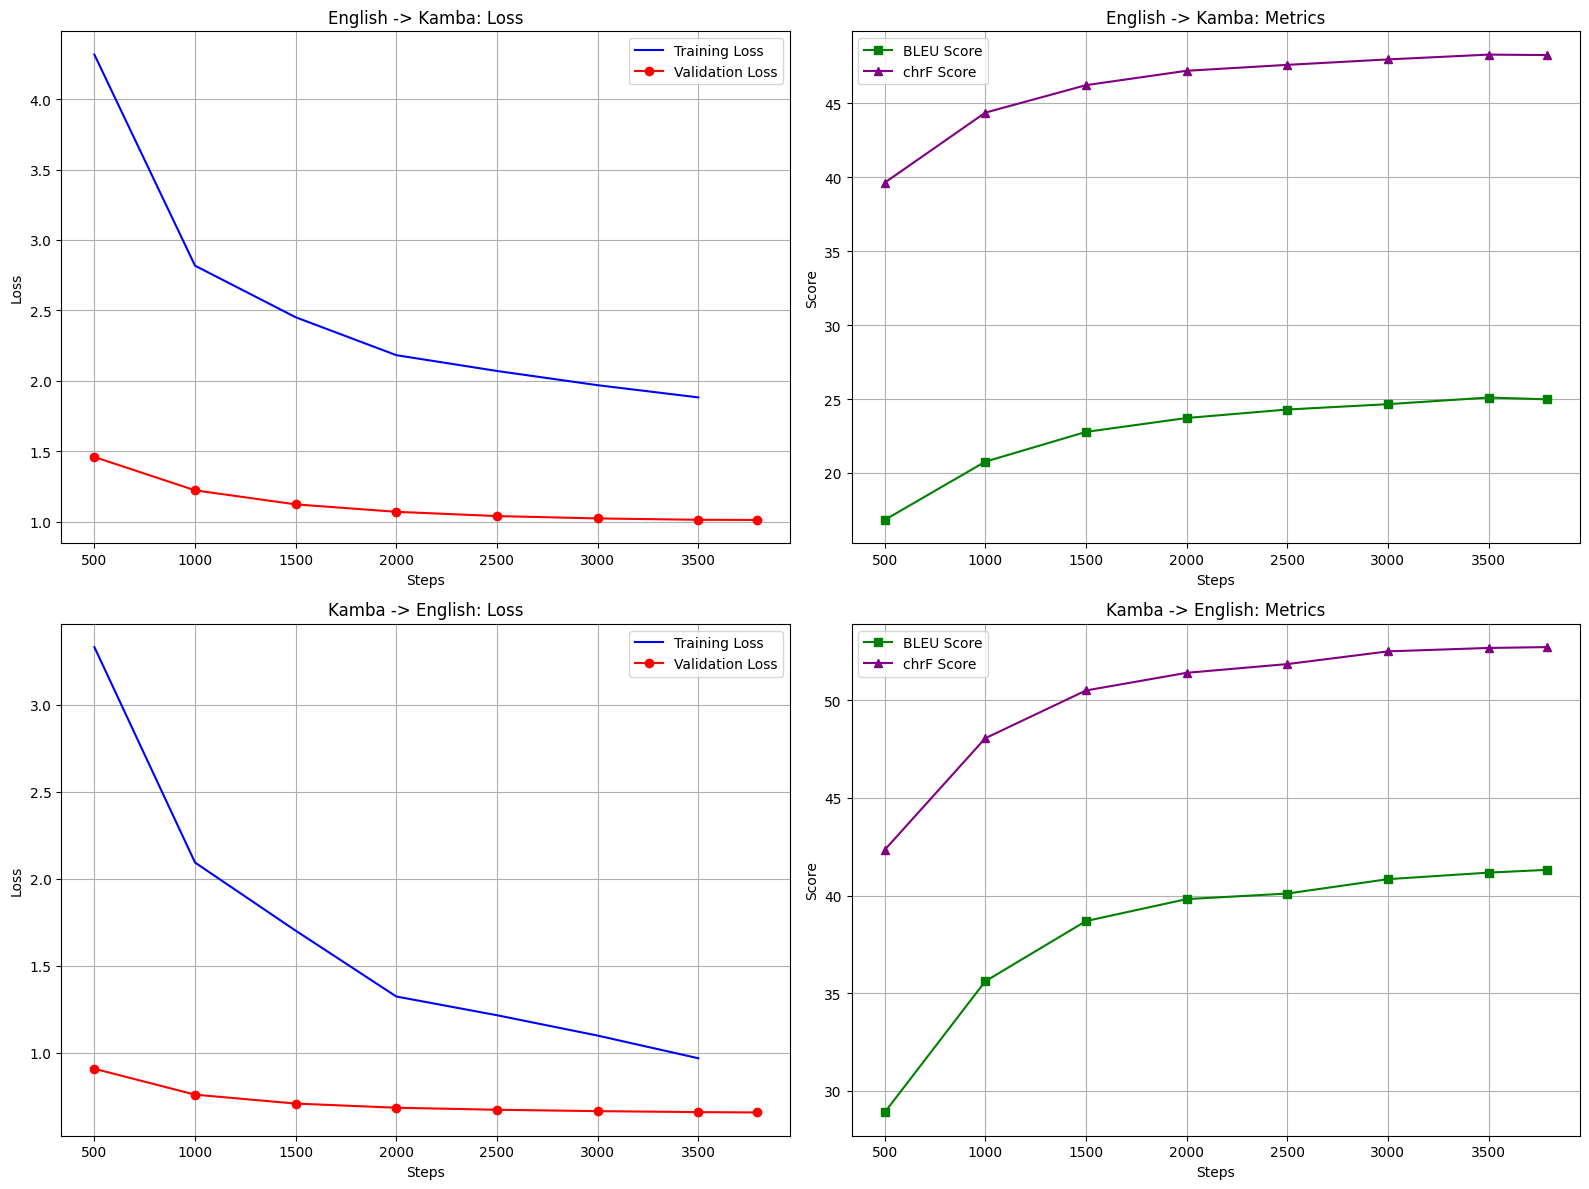

In [8]:
import matplotlib.pyplot as plt

def extract_metrics(history):
    train_steps, train_loss, eval_steps, eval_loss, eval_bleu, eval_chrf = [], [], [], [], [], []
    for entry in history:
        if 'loss' in entry and 'step' in entry:
            train_steps.append(entry['step'])
            train_loss.append(entry['loss'])
        elif 'eval_loss' in entry and 'step' in entry:
            eval_steps.append(entry['step'])
            eval_loss.append(entry['eval_loss'])
            if 'eval_bleu' in entry:
                eval_bleu.append(entry['eval_bleu'])
            if 'eval_chrf' in entry:
                eval_chrf.append(entry['eval_chrf'])
    return train_steps, train_loss, eval_steps, eval_loss, eval_bleu, eval_chrf

t_steps_en, t_loss_en, e_steps_en, e_loss_en, bleu_en, chrf_en = extract_metrics(log_history_en_kam)
t_steps_kam, t_loss_kam, e_steps_kam, e_loss_kam, bleu_kam, chrf_kam = extract_metrics(log_history_kam_en)

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Row 1, Col 1: EN->KAM Loss
axs[0, 0].plot(t_steps_en, t_loss_en, label='Training Loss', color='blue')
axs[0, 0].plot(e_steps_en, e_loss_en, label='Validation Loss', color='red', marker='o')
axs[0, 0].set_title('English -> Kamba: Loss')
axs[0, 0].set_xlabel('Steps')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Row 1, Col 2: EN->KAM Metrics
if bleu_en and chrf_en:
    axs[0, 1].plot(e_steps_en, bleu_en, label='BLEU Score', color='green', marker='s')
    axs[0, 1].plot(e_steps_en, chrf_en, label='chrF Score', color='purple', marker='^')
    axs[0, 1].set_title('English -> Kamba: Metrics')
    axs[0, 1].set_xlabel('Steps')
    axs[0, 1].set_ylabel('Score')
    axs[0, 1].legend()
    axs[0, 1].grid(True)
else:
    axs[0, 1].text(0.5, 0.5, 'No metrics found', horizontalalignment='center')
    axs[0, 1].set_title('English -> Kamba: Metrics')

# Row 2, Col 1: KAM->EN Loss
axs[1, 0].plot(t_steps_kam, t_loss_kam, label='Training Loss', color='blue')
axs[1, 0].plot(e_steps_kam, e_loss_kam, label='Validation Loss', color='red', marker='o')
axs[1, 0].set_title('Kamba -> English: Loss')
axs[1, 0].set_xlabel('Steps')
axs[1, 0].set_ylabel('Loss')
axs[1, 0].legend()
axs[1, 0].grid(True)

# Row 2, Col 2: KAM->EN Metrics
if bleu_kam and chrf_kam:
    axs[1, 1].plot(e_steps_kam, bleu_kam, label='BLEU Score', color='green', marker='s')
    axs[1, 1].plot(e_steps_kam, chrf_kam, label='chrF Score', color='purple', marker='^')
    axs[1, 1].set_title('Kamba -> English: Metrics')
    axs[1, 1].set_xlabel('Steps')
    axs[1, 1].set_ylabel('Score')
    axs[1, 1].legend()
    axs[1, 1].grid(True)
else:
    axs[1, 1].text(0.5, 0.5, 'No metrics found', horizontalalignment='center')
    axs[1, 1].set_title('Kamba -> English: Metrics')

plt.tight_layout()
plt.show()

## 7. Bidirectional Interactive Translation (Gradio)


In [9]:
import os

import torch
import math
import gradio as gr
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import logging
import logging
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)
logging.getLogger("accelerate.utils.modeling").setLevel(logging.ERROR)
logging.getLogger("accelerate.big_modeling").setLevel(logging.ERROR)
logging.getLogger("accelerate").setLevel(logging.ERROR)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading English -> Kamba model...")
tokenizer_en_kam = AutoTokenizer.from_pretrained(final_model_dir_en_kam)
model_en_kam = AutoModelForSeq2SeqLM.from_pretrained(final_model_dir_en_kam).to(device)
model_en_kam.eval()

print("Loading Kamba -> English model...")
tokenizer_kam_en = AutoTokenizer.from_pretrained(final_model_dir_kam_en)
model_kam_en = AutoModelForSeq2SeqLM.from_pretrained(final_model_dir_kam_en).to(device)
model_kam_en.eval()

def translate_bidirectional(text, direction):
    if not text.strip():
        return "", ""
        
    if direction == "English to Kamba":
        tokenizer = tokenizer_en_kam
        model = model_en_kam
    else:
        tokenizer = tokenizer_kam_en
        model = model_kam_en
        
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_length=128, 
            num_beams=4, 
            early_stopping=True,
            return_dict_in_generate=True,
            output_scores=True
        )
        
    translation = tokenizer.decode(outputs.sequences[0], skip_special_tokens=True)
    
    seq_score = outputs.sequences_scores[0].item()
    confidence = torch.exp(torch.tensor(seq_score)).item() * 100
    
    return translation, f"{confidence:.1f}%"

with gr.Blocks(theme="default") as demo:
    gr.Markdown("# Bidirectional Kamba Translator")
    gr.Markdown("Marian NMT architecture fully fine-tuned on Kamba-English sentence pairs.")
    
    with gr.Row():
        direction = gr.Radio(["English to Kamba", "Kamba to English"], label="Translation Direction", value="English to Kamba")
        
    with gr.Row():
        input_text = gr.Textbox(lines=3, placeholder="Enter text here...", label="Input Text")
        with gr.Column():
            output_text = gr.Textbox(lines=3, label="Translation")
            conf_label = gr.Label(label="Confidence Score")
            
    translate_btn = gr.Button("Translate")
    
    translate_btn.click(
        fn=translate_bidirectional,
        inputs=[input_text, direction],
        outputs=[output_text, conf_label]
    )

demo.launch(share=True, debug=True)

Loading English -> Kamba model...


The following layers were not sharded: final_logits_bias, model.shared.weight, model.decoder.layers.*.self_attn.v_proj.bias, model.decoder.layers.*.encoder_attn.k_proj.bias, model.decoder.layers.*.encoder_attn.out_proj.weight, model.decoder.layers.*.encoder_attn.v_proj.weight, model.decoder.layers.*.encoder_attn.out_proj.bias, model.decoder.layers.*.self_attn.k_proj.bias, model.encoder.embed_tokens.weight, model.decoder.layers.*.fc1.weight, model.decoder.layers.*.self_attn.q_proj.bias, model.encoder.layers.*.fc2.bias, model.encoder.layers.*.self_attn.v_proj.weight, model.encoder.layers.*.final_layer_norm.bias, model.decoder.layers.*.encoder_attn.v_proj.bias, model.encoder.layers.*.final_layer_norm.weight, model.decoder.embed_tokens.weight, model.encoder.layers.*.self_attn_layer_norm.weight, model.encoder.layers.*.fc1.bias, model.encoder.layers.*.fc2.weight, model.encoder.embed_positions.weight, model.decoder.layers.*.fc1.bias, model.encoder.layers.*.self_attn.k_proj.bias, model.decoder

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

The following layers were not sharded: final_logits_bias, model.shared.weight, model.decoder.layers.*.self_attn.v_proj.bias, model.decoder.layers.*.encoder_attn.k_proj.bias, model.decoder.layers.*.encoder_attn.out_proj.weight, model.decoder.layers.*.encoder_attn.v_proj.weight, model.decoder.layers.*.encoder_attn.out_proj.bias, model.decoder.layers.*.self_attn.k_proj.bias, model.encoder.embed_tokens.weight, model.decoder.layers.*.fc1.weight, model.decoder.layers.*.self_attn.q_proj.bias, model.encoder.layers.*.fc2.bias, model.encoder.layers.*.self_attn.v_proj.weight, model.encoder.layers.*.final_layer_norm.bias, model.decoder.layers.*.encoder_attn.v_proj.bias, model.encoder.layers.*.final_layer_norm.weight, model.decoder.embed_tokens.weight, model.encoder.layers.*.self_attn_layer_norm.weight, model.encoder.layers.*.fc1.bias, model.encoder.layers.*.fc2.weight, model.encoder.embed_positions.weight, model.decoder.layers.*.fc1.bias, model.encoder.layers.*.self_attn.k_proj.bias, model.decoder

Loading Kamba -> English model...


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://107671ff06bf53823d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://107671ff06bf53823d.gradio.live
